In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("heart_disease_uci.csv")

In [3]:
print("Shape: ", df.shape)
print("\nColumn Types: \n", df.dtypes)
print("\nMissing Values: \n", df.isnull().sum())

Shape:  (920, 16)

Column Types: 
 id            int64
age           int64
sex          object
dataset      object
cp           object
trestbps    float64
chol        float64
fbs          object
restecg      object
thalch      float64
exang        object
oldpeak     float64
slope        object
ca          float64
thal         object
num           int64
dtype: object

Missing Values: 
 id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64


In [4]:
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [5]:
print("Original 'num' distribution: \n ", df['num'].value_counts().sort_index())

df['target'] = (df['num'] > 0).astype(int)

print("\nBinary target distribution: \n", df['target'].value_counts())

Original 'num' distribution: 
  num
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64

Binary target distribution: 
 target
1    509
0    411
Name: count, dtype: int64


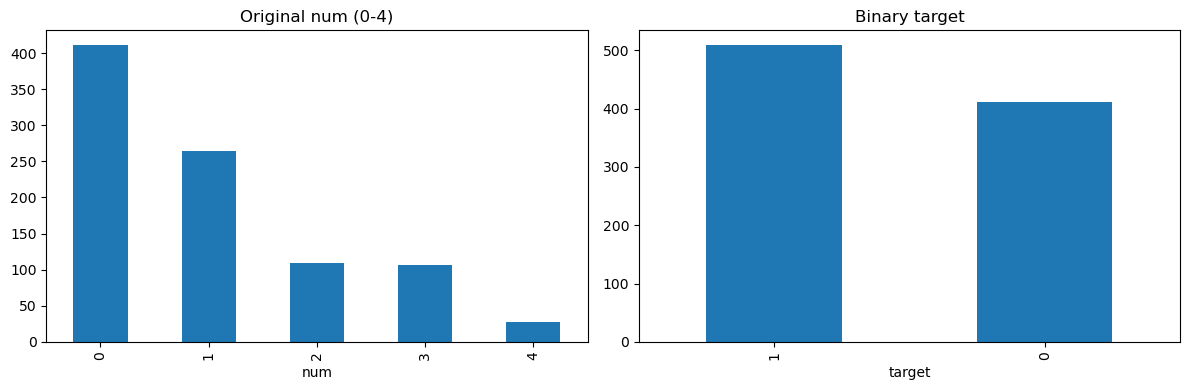

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['num'].value_counts().sort_index().plot(kind='bar', ax=axes[0], title="Original num (0-4)")
df['target'].value_counts().plot(kind="bar", ax=axes[1], title="Binary target")
plt.tight_layout()
plt.show()

                     ca      thal     slope  trestbps      chol    thalch
dataset                                                                  
Cleveland      0.016447  0.009868  0.003289  0.000000  0.000000  0.000000
Hungary        0.989761  0.904437  0.645051  0.003413  0.078498  0.003413
Switzerland    0.959350  0.422764  0.138211  0.016260  0.000000  0.008130
VA Long Beach  0.990000  0.830000  0.510000  0.280000  0.035000  0.265000


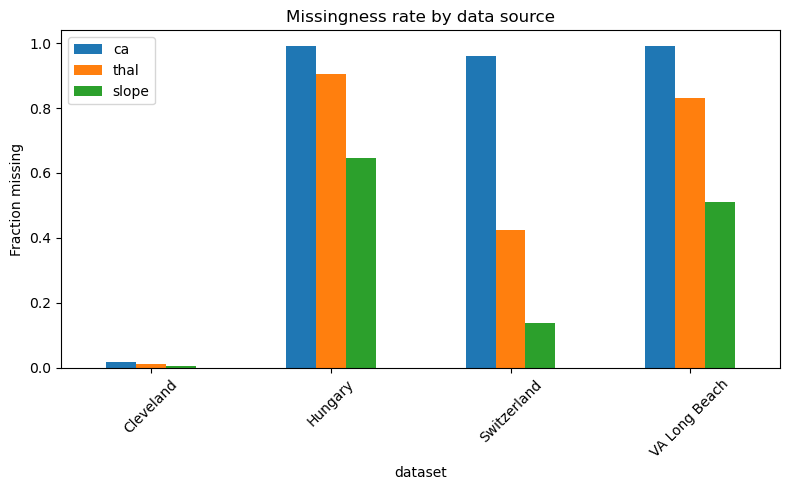

In [7]:
missing_by_site = df.groupby('dataset')[['ca', 'thal', 'slope', 'trestbps', 'chol', 'thalch']].apply(lambda x: x.isnull().mean())
print(missing_by_site)

missing_by_site[['ca', 'thal', 'slope']].plot(kind='bar', figsize=(8,5))
plt.title('Missingness rate by data source')
plt.ylabel('Fraction missing')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Since less than 5% of data is missing for 'trestbps', 'chol' & 'thalch' Complete Case Analysis (CCA) / remove them can be applied for them
# For the other three more than 5% data is missing so CCA can't be applied

### trestbps and chol distribution before fixing 0 values

trestbps == 0 count:  1
chol == 0 count:  172

trestbps == 0 by site
dataset
VA Long Beach    1
dtype: int64

chol == 0 by site
dataset
Switzerland      123
VA Long Beach     49
dtype: int64


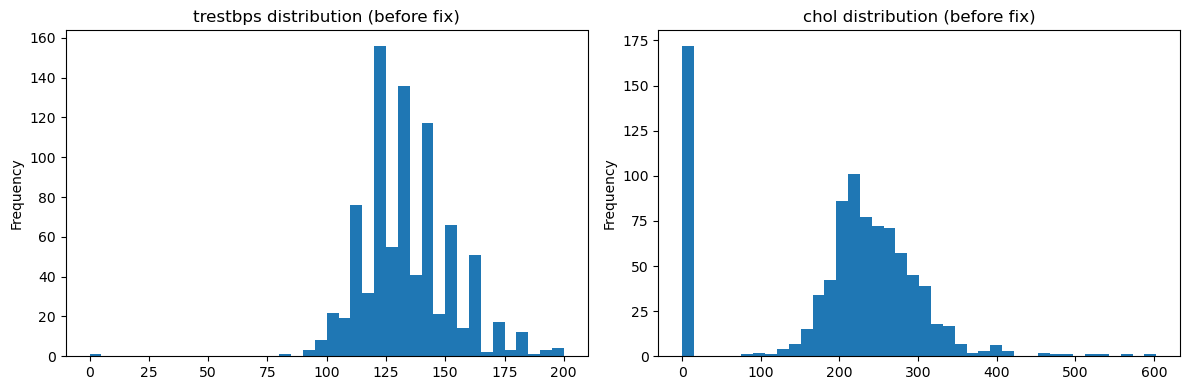

In [8]:
print("trestbps == 0 count: ", (df['trestbps'] == 0).sum())
print("chol == 0 count: ", (df['chol'] == 0).sum())

print("\ntrestbps == 0 by site")
print(df[df['trestbps'] == 0].groupby('dataset').size())

print("\nchol == 0 by site")
print(df[df['chol'] == 0].groupby('dataset').size())

fig, axes = plt.subplots(1, 2, figsize=(12,4))
df['trestbps'].plot(kind='hist', bins=40, ax=axes[0], title='trestbps distribution (before fix)')
df['chol'].plot(kind='hist', bins=40, ax=axes[1], title='chol distribution (before fix)')
plt.tight_layout()
plt.show()

### trestbps and chol distribution after fixing 0 values


Updated missing value counts:
trestbps     60
chol        202
dtype: int64

Updated missingness by site:
               trestbps      chol
dataset                          
Cleveland      0.000000  0.000000
Hungary        0.003413  0.078498
Switzerland    0.016260  1.000000
VA Long Beach  0.285000  0.280000


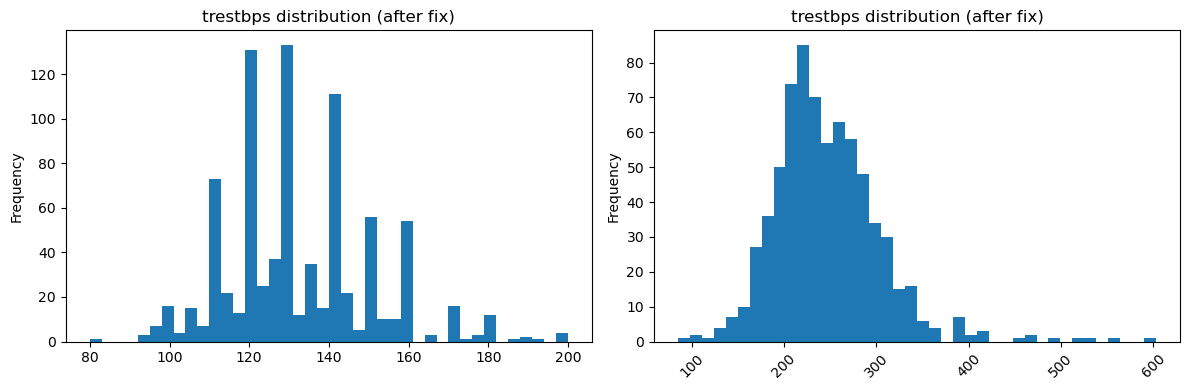

In [9]:
df['trestbps'] = df['trestbps'].replace(0, np.nan)
df['chol'] = df['chol'].replace(0, np.nan)

print("\nUpdated missing value counts:")
print(df[['trestbps', 'chol']].isnull().sum())

print("\nUpdated missingness by site:")
print(df.groupby('dataset')[['trestbps', 'chol']].apply(lambda x: x.isnull().mean()))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['trestbps'].plot(kind='hist', bins=40, ax=axes[0], title='trestbps distribution (after fix)')
df['chol'].plot(kind='hist', bins=40, ax=axes[1], title='trestbps distribution (after fix)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Numerical features vs target

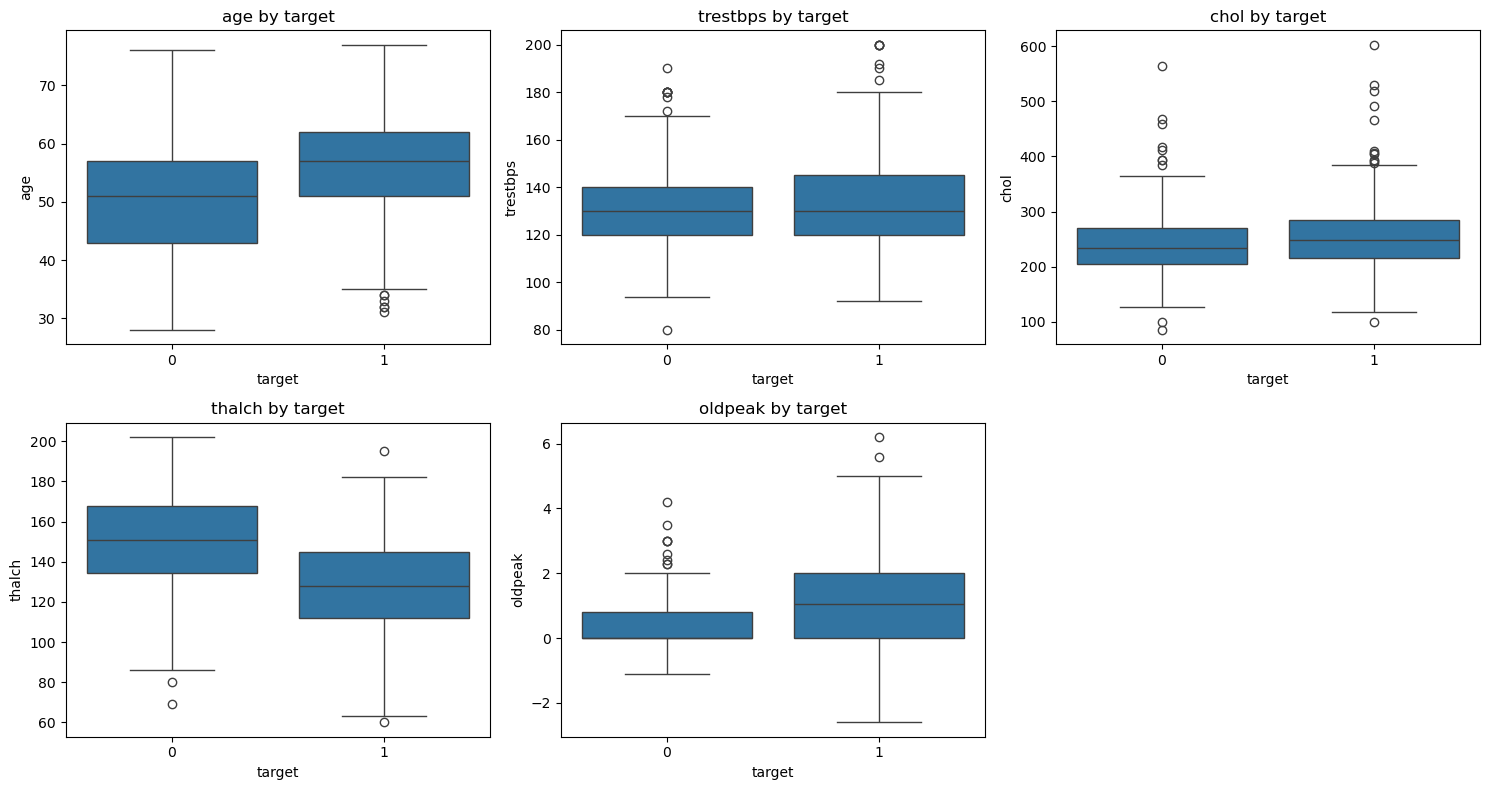

In [10]:
numeric_features = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']

fig, axes = plt.subplots(2, 3, figsize=(15,8))
axes = axes.flatten()
for i, col in enumerate(numeric_features):
    sns.boxplot(data=df, x='target', y=col, ax=axes[i])
    axes[i].set_title(f'{col} by target')
axes[5].set_visible(False)
plt.tight_layout()
plt.show()

### Categorical features vs target

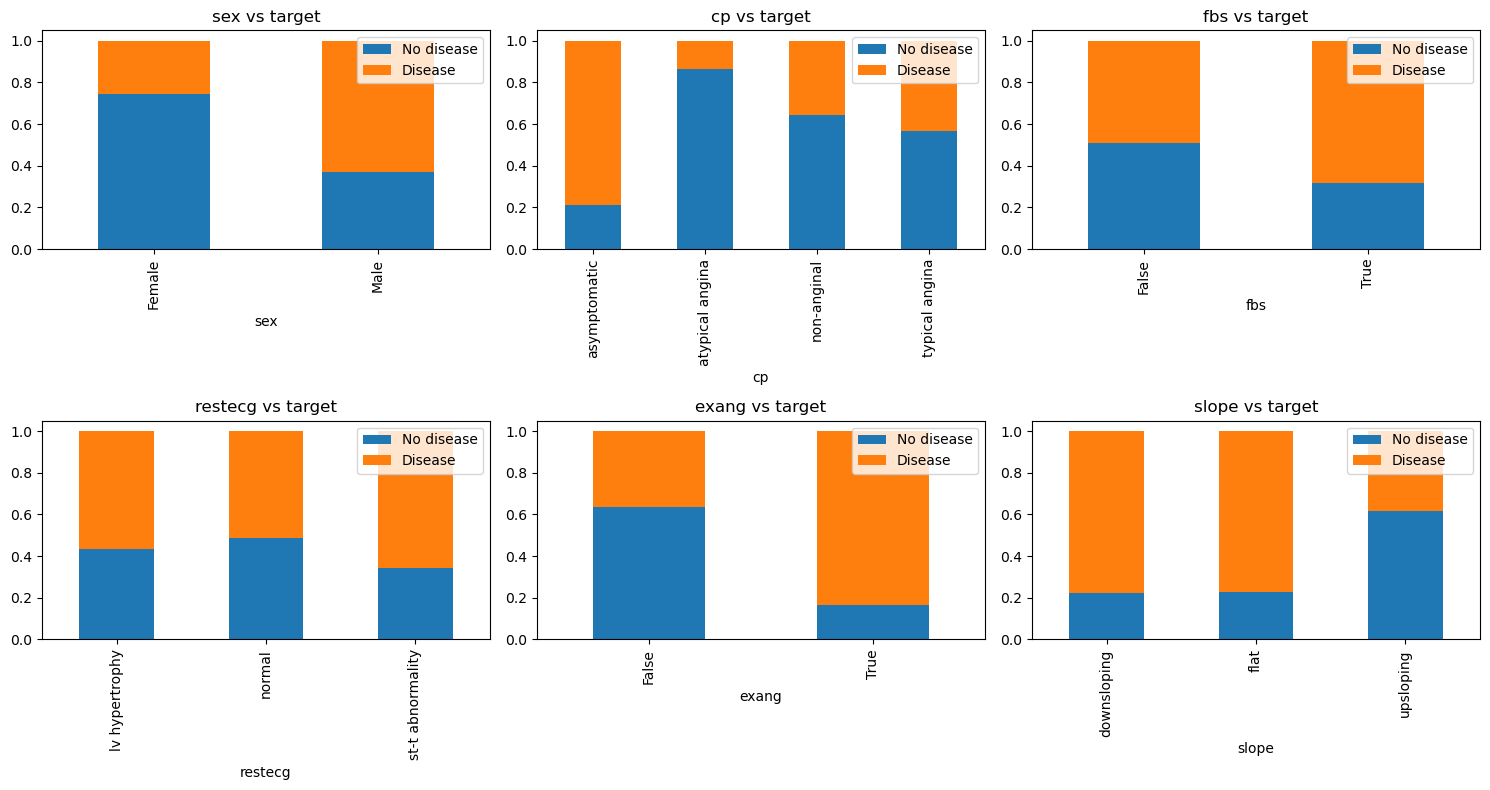

In [11]:
categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(categorical_features):
    pd.crosstab(df[col], df['target'], normalize='index').plot(kind='bar', stacked=True, ax=axes[i])
    axes[i].set_title(f'{col} vs target')
    axes[i].legend(['No disease', 'Disease'])
plt.tight_layout()
plt.show()

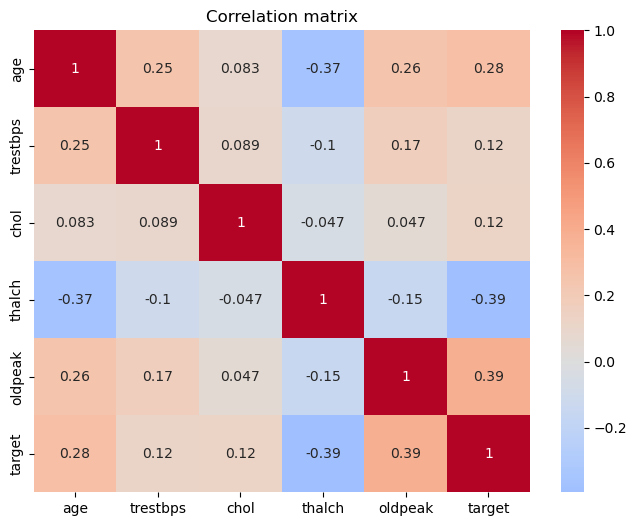

In [12]:
plt.figure(figsize=(8,6))
sns.heatmap(df[numeric_features + ['target']].corr(), annot=True, cmap="coolwarm", center=0)
plt.title('Correlation matrix')
plt.show()

In [13]:
df_model = df.drop(columns=['id', 'num', 'ca', 'thal', 'dataset'])

X = df_model.drop(columns=['target'])
y = df_model['target']

print("Final feature column:", X.columns.to_list())
print("Shape:", X.shape)

Final feature column: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope']
Shape: (920, 11)


### Train Test Split

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
print("Train target balance:\n", y_train.value_counts(normalize=True))
print("Test target balance:\n", y_test.value_counts(normalize=True))

Train shape: (736, 11) Test shape: (184, 11)
Train target balance:
 target
1    0.552989
0    0.447011
Name: proportion, dtype: float64
Test target balance:
 target
1    0.554348
0    0.445652
Name: proportion, dtype: float64


### Preprocessing

In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_features = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']
categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix)

### Logistic Regression

In [17]:
lr_pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])

lr_param_grid = {
    'model__C': [0.01, 0.1, 1, 10, 100],
    'model__l1_ratio': [0.0, 1.0],
    'model__solver': ['saga']
}

lr_grid = GridSearchCV(
    lr_pipeline, lr_param_grid, cv=5, scoring='f1', n_jobs=-1
)

lr_grid.fit(X_train, y_train)

print("Best params:", lr_grid.best_params_)
print("Best CV F1 score:", lr_grid.best_score_)

Best params: {'model__C': 0.1, 'model__l1_ratio': 0.0, 'model__solver': 'saga'}
Best CV F1 score: 0.8254202686183258


### Decision Tree 

In [18]:
dt_pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('model', DecisionTreeClassifier(random_state=42))
])

dt_param_grid = {
    'model__max_depth': [3, 5, 7, 10, None],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4]
}

dt_grid = GridSearchCV(
    dt_pipeline, dt_param_grid, cv=5, scoring='f1', n_jobs=-1
)

dt_grid.fit(X_train, y_train)

print("Best params:", dt_grid.best_params_)
print("Best CV F1 score:", dt_grid.best_score_)

Best params: {'model__max_depth': 5, 'model__min_samples_leaf': 4, 'model__min_samples_split': 10}
Best CV F1 score: 0.7841319109947833


### Random forest

In [19]:
rf_pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('model', RandomForestClassifier(random_state=42))
])

rf_param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [5, 10, None],
    'model__min_samples_split': [2, 5],
    'model__max_features': ['sqrt', 'log2']
}

rf_grid = GridSearchCV(
    rf_pipeline, rf_param_grid, cv=5, scoring='f1', n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Best params:", rf_grid.best_params_)
print("Best CV F1 score:", rf_grid.best_score_)

Best params: {'model__max_depth': 5, 'model__max_features': 'sqrt', 'model__min_samples_split': 5, 'model__n_estimators': 200}
Best CV F1 score: 0.8366991708223427


### XGBoost 

In [20]:
xgb_pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('model', XGBClassifier(eval_metric='logloss', random_state=42))
])

xgb_param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [3, 5, 7],
    'model__learning_rate': [0.01, 0.1, 0.2],
    'model__subsample': [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    xgb_pipeline, xgb_param_grid, cv=5, scoring='f1', n_jobs=-1
)

xgb_grid.fit(X_train, y_train)

print("Best params:", xgb_grid.best_params_)
print("Best CV F1 score:", xgb_grid.best_score_)

Best params: {'model__learning_rate': 0.01, 'model__max_depth': 3, 'model__n_estimators': 300, 'model__subsample': 1.0}
Best CV F1 score: 0.8316263104814089


### Evaluation on Test Set

In [21]:
models = {
    'Logistic Regression': lr_grid.best_estimator_,
    'Decision Tree': dt_grid.best_estimator_,
    'RandomForest': rf_grid.best_estimator_,
    'XGBoost': xgb_grid.best_estimator_
}

results = []
for name, model in models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    })


results_df = pd.DataFrame(results).set_index('Model').round(3)
print(results_df)

                     Accuracy  Precision  Recall     F1  ROC-AUC
Model                                                           
Logistic Regression     0.793      0.796   0.843  0.819    0.888
Decision Tree           0.777      0.780   0.833  0.806    0.843
RandomForest            0.793      0.796   0.843  0.819    0.907
XGBoost                 0.788      0.779   0.863  0.819    0.903


### Confusion matrix

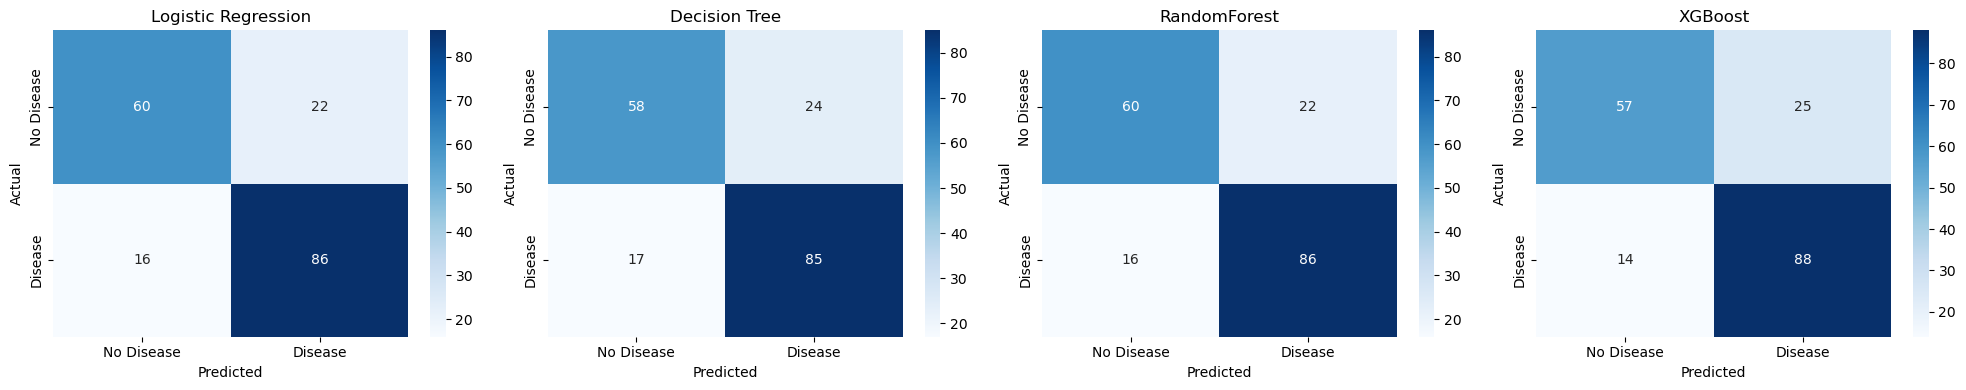

In [22]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'])
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

### ROC Curves

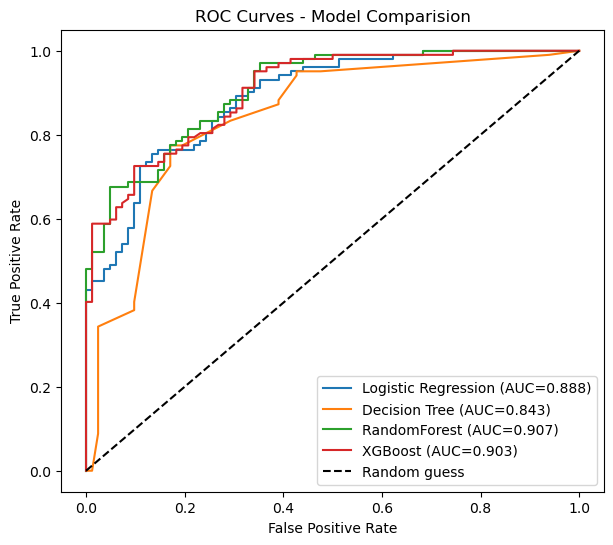

In [23]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(7, 6))
for name, model in models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

plt.plot([0,1], [0,1], 'k--', label="Random guess")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Model Comparision')
plt.legend()
plt.show()

C:\Users\vinay\.conda\envs\ml_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


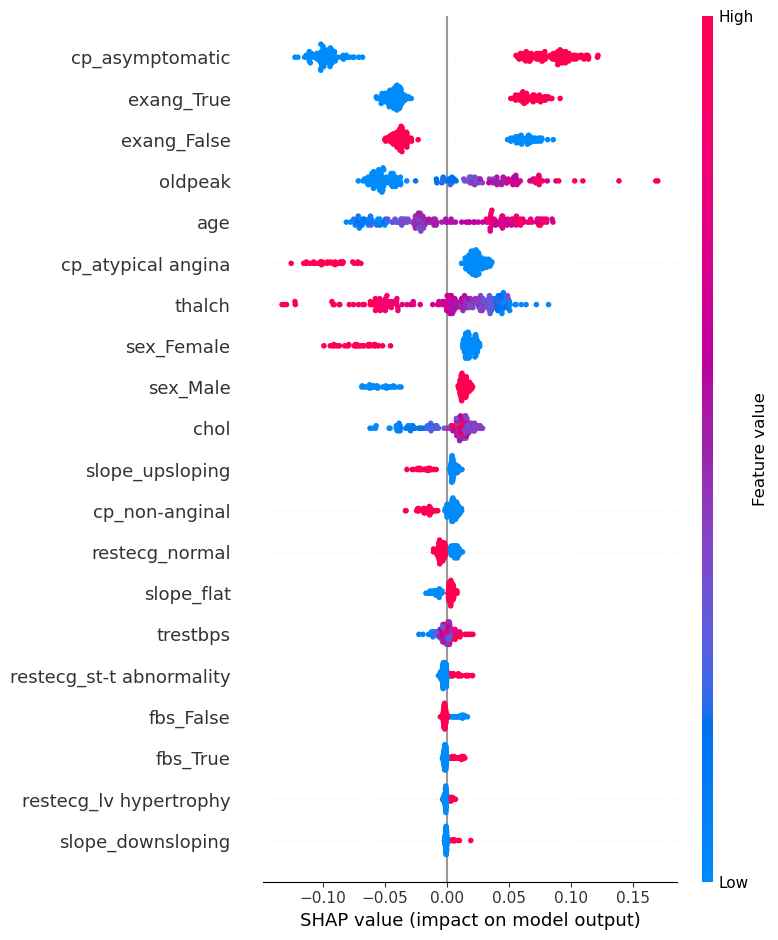

In [24]:
import shap

final_model = rf_grid.best_estimator_

feature_names = (
    numeric_features +
    list(final_model.named_steps['preprocessing']
         .named_transformers_['cat']
         .named_steps['encoder']
         .get_feature_names_out(categorical_features))
)

X_test_transformed = final_model.named_steps['preprocessing'].transform(X_test)

rf_model_only = final_model.named_steps['model']

explainer = shap.TreeExplainer(rf_model_only)
shap_values = explainer.shap_values(X_test_transformed)

shap_values_class1 = shap_values[:, :, 1]

shap.summary_plot(shap_values_class1, X_test_transformed, feature_names=feature_names)

Misclassified: 38 out of 184
False negatives: 16
False positives: 22


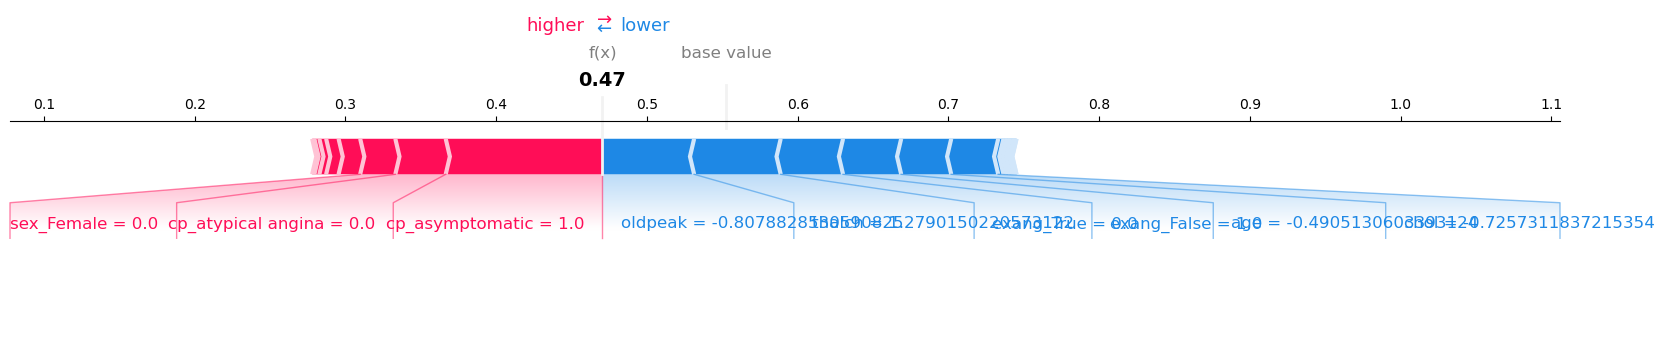

In [25]:
y_pred_rf = final_model.predict(X_test)
misclassified_mask = (y_pred_rf != y_test.values)

print(f"Misclassified: {misclassified_mask.sum()} out of {len(y_test)}")

false_negatives = (y_pred_rf == 0) & (y_test.values == 1)  
false_positives = (y_pred_rf == 1) & (y_test.values == 0) 

print(f"False negatives: {false_negatives.sum()}")
print(f"False positives: {false_positives.sum()}")

misclassified_indices = np.where(misclassified_mask)[0]
example_idx = misclassified_indices[0]

shap.force_plot(
    explainer.expected_value[1],
    shap_values_class1[example_idx],
    X_test_transformed[example_idx],
    feature_names=feature_names,
    matplotlib=True
)

In [26]:
y_proba_rf = final_model.predict_proba(X_test)[:, 1]
print("Predicted probabilities for misclassified patients:")
print(y_proba_rf[misclassified_mask])

Predicted probabilities for misclassified patients:
[0.47045723 0.56148834 0.78876437 0.41191523 0.30427548 0.64892019
 0.39949438 0.78821199 0.40875524 0.35412868 0.61052793 0.65070021
 0.16583867 0.65278358 0.38656245 0.68982655 0.52989199 0.67253565
 0.52404903 0.4429932  0.66808835 0.39256244 0.48875502 0.48619333
 0.43619936 0.69109771 0.68107698 0.49996711 0.43264008 0.79674123
 0.52213392 0.39048493 0.74638167 0.55975839 0.58206546 0.6030512
 0.57476798 0.62671502]


### Importing final model

In [29]:
import joblib

joblib.dump(final_model, 'final_model.joblib')

['final_model.joblib']